<a href="https://colab.research.google.com/github/brieueu/Roblox_data/blob/main/Roblox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

José Gabriel

In [77]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("biggiefats/roblox-games-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/roblox-games-dataset


In [78]:
import os

files = os.listdir(path)
print("Files in the downloaded directory:", files)

Files in the downloaded directory: ['roblox_games.csv']


In [79]:
import pandas as pd
import os

file_path = os.path.join(path, 'roblox_games.csv')
df = pd.read_csv(file_path)
display(df)

,Rank,Name,Active,Visits,Favourites,Likes,Dislikes,Rating
0,#1,Blox Fruits,"483,372","41,346,317,182","13,574,097","8,521,670","676,846",92.64
1,#2,Brookhaven 🏡RP,"474,141","55,635,148,446","22,117,653","6,108,763","955,845",86.47
2,#3,Dress To Impress 💜,"297,764","3,876,511,994","3,182,036","2,042,092","188,403",91.55
3,#4,PETS GO! ✨ [NEW],"172,411","145,691,211","199,254","275,267","20,140",93.18
4,#5,Murder Mystery 2,"159,531","18,310,453,247","19,306,585","8,001,198","786,705",91.05
...,...,...,...,...,...,...,...,...
995,#996,[MOBILE/CONSOLE FIXED - BETA] The Time of Ninja,706,"5,136,808","80,497","25,291","2,841",89.90
996,#997,TEAM BORRY PRISON BREAKOUT!👮 [TEAMWORK OBBY],705,"68,323,047","15,351","1,397",586,70.45
997,#998,[👻HALLOWEEN] ADC DANCE STUDIO,704,"11,811,628","8,996","4,344",429,91.01
998,#999,🏈 Field Goal Simulator,703,"43,992,091","411,025","37,371","6,273",85.63


# Tratando a base de dados

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rank        1000 non-null   object 
 1   Name        1000 non-null   object 
 2   Active      1000 non-null   object 
 3   Visits      1000 non-null   object 
 4   Favourites  1000 non-null   object 
 5   Likes       1000 non-null   object 
 6   Dislikes    1000 non-null   object 
 7   Rating      1000 non-null   float64
dtypes: float64(1), object(7)
memory usage: 62.6+ KB


In [81]:
print(df.duplicated().sum())
df = df.drop_duplicates()

20


In [82]:
colunas = ["Active", "Visits", "Favourites", "Likes", "Dislikes"]
df[colunas] = (
    df[colunas]
    .replace(",", "", regex=True)
    .fillna(0)
    .astype(int)
)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 980 entries, 0 to 999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Rank        980 non-null    object 
 1   Name        980 non-null    object 
 2   Active      980 non-null    int64  
 3   Visits      980 non-null    int64  
 4   Favourites  980 non-null    int64  
 5   Likes       980 non-null    int64  
 6   Dislikes    980 non-null    int64  
 7   Rating      980 non-null    float64
dtypes: float64(1), int64(5), object(2)
memory usage: 68.9+ KB


/tmp/ipython-input-82-4043593272.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[colunas] = (


# Analyze

In [83]:
# Ordenações
Top_ativos = df.sort_values(by="Active", ascending=False)
Top_visitas = df.sort_values(by="Visits", ascending=False)
Top_favoritos = df.sort_values(by="Favourites", ascending=False)
Top_gostos = df.sort_values(by="Likes", ascending=False)
Top_desgostos = df.sort_values(by="Dislikes", ascending=False)
Top_classificacao = df.sort_values(by="Rating", ascending=False)


In [84]:
print("Top por jogadores ativos:")
display(Top_ativos.head())

print("Top por visitas:")
display(Top_visitas.head())

print("Top por favoritos:")
display(Top_favoritos.head())

print("Top por curtidas:")
display(Top_gostos.head())

print("Top por desgostos:")
display(Top_desgostos.head())

print("Top por classificação (Likes / Dislikes):")
display(Top_classificacao.head())


Top por jogadores ativos:


,Rank,Name,Active,Visits,Favourites,Likes,Dislikes,Rating
0,#1,Blox Fruits,483372,41346317182,13574097,8521670,676846,92.64
1,#2,Brookhaven 🏡RP,474141,55635148446,22117653,6108763,955845,86.47
2,#3,Dress To Impress 💜,297764,3876511994,3182036,2042092,188403,91.55
3,#4,PETS GO! ✨ [NEW],172411,145691211,199254,275267,20140,93.18
4,#5,Murder Mystery 2,159531,18310453247,19306585,8001198,786705,91.05


Top por visitas:


,Rank,Name,Active,Visits,Favourites,Likes,Dislikes,Rating
1,#2,Brookhaven 🏡RP,474141,55635148446,22117653,6108763,955845,86.47
0,#1,Blox Fruits,483372,41346317182,13574097,8521670,676846,92.64
8,#9,Adopt Me!,109439,37679655130,26994071,7323639,1441230,83.56
80,#81,Tower of Hell,10517,23977099438,11167470,3861874,1350060,74.10
4,#5,Murder Mystery 2,159531,18310453247,19306585,8001198,786705,91.05


Top por favoritos:


...

,Rank,Name,Active,Visits,Favourites,Likes,Dislikes,Rating
0,#1,Blox Fruits,483372,41346317182,13574097,8521670,676846,92.64
4,#5,Murder Mystery 2,159531,18310453247,19306585,8001198,786705,91.05
8,#9,Adopt Me!,109439,37679655130,26994071,7323639,1441230,83.56
21,#22,[UPD] Blade Ball,34558,4482377254,9966828,6487048,444810,93.58
1,#2,Brookhaven 🏡RP,474141,55635148446,22117653,6108763,955845,86.47


Top por desgostos:


,Rank,Name,Active,Visits,Favourites,Likes,Dislikes,Rating
8,#9,Adopt Me!,109439,37679655130,26994071,7323639,1441230,83.56
80,#81,Tower of Hell,10517,23977099438,11167470,3861874,1350060,74.10
1,#2,Brookhaven 🏡RP,474141,55635148446,22117653,6108763,955845,86.47
4,#5,Murder Mystery 2,159531,18310453247,19306585,8001198,786705,91.05
51,#52,Jailbreak 🍁,16044,7121330094,18267940,5531874,770054,87.78


Top por classificação (Likes / Dislikes):


,Rank,Name,Active,Visits,Favourites,Likes,Dislikes,Rating
931,#932,Climb Race Simulator,749,17843797,44887,154198,2202,98.59
537,#538,Dunk Battles!,1320,2383311,13142,51411,769,98.53
532,#533,[🎃UPD] Cake Off!,1336,41264385,2516059,416037,7161,98.31
877,#878,SKYDIVE Off A TOWER! 🪂,804,97288420,1995554,668765,12149,98.22
955,#956,Kart Racing Simulator,733,14985646,913320,166930,3288,98.07


Retenção é a quantidade de pessoa visitaram o jogo pela quantidade de Active

In [85]:
df["Retencao"] = df["Active"] / df["Visits"].replace(0, 1)
Top_retencao = df.sort_values(by="Retencao", ascending=False)
print("Top jogos por retenção (ativos / visitas):")
display(Top_retencao.head())


Top jogos por retenção (ativos / visitas):


,Rank,Name,Active,Visits,Favourites,Likes,Dislikes,Rating,Retencao
901,#902,Destroy Grandma,777,28198,281,78,13,85.71,0.027555
577,#578,Pokemon Brick Bronze | Bronze Reborn,1212,124153,1069,288,44,86.75,0.009762
340,#341,Pokemon Brick Bronze | Roria Conquest,2172,261636,3035,880,61,93.52,0.008302
254,#255,😈 TRAITOR!,2960,369074,34724,212,49,81.23,0.008020
140,#141,BACK! / MMV,5222,790643,54804,805,39,95.38,0.006605


Relação de Likes de Deslikes

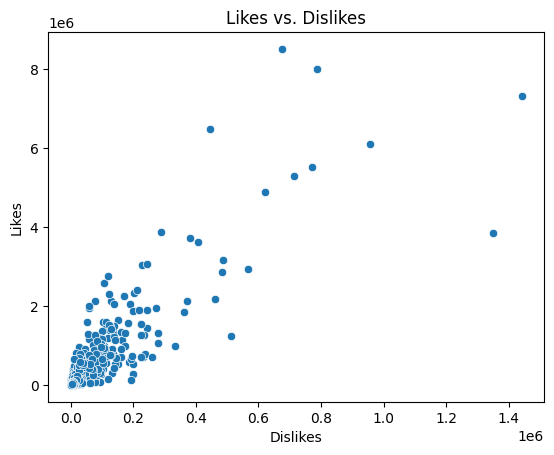

In [88]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=df, x="Dislikes", y="Likes")
plt.title("Likes vs. Dislikes")
plt.show()


Jogos com alto engajamento, mas tô tendo problema na retenção, pois pela equação pressupoe que todos os games chegaram agora com isso temos uma vantagem de games mais recentes aparecerem primeiro.

In [95]:
# Jogos com alta retenção (por exemplo, top 100)
Top_retencao = df.sort_values(by="Retencao", ascending=False).head(100)

# Interseção dos nomes em várias métricas
names = (
    set(Top_favoritos["Name"])
    & set(Top_retencao["Name"])
    & set(Top_visitas["Name"])
    & set(Top_gostos["Name"])
)

print("Games with high engagement (including retention, excluding rating):")
df_top3games = df[df["Name"].isin(names)]
display(df_top3games)


Games with high engagement (including retention, excluding rating):


,Rank,Name,Active,Visits,Favourites,Likes,Dislikes,Rating,Retencao
3,#4,PETS GO! ✨ [NEW],172411,145691211,199254,275267,20140,93.18,0.001183
16,#17,[🎃] Fisch,44174,23455912,149970,74557,9433,88.77,0.001883
35,#36,🎃 Hide or Die!,24358,34061192,1326949,17487,4724,78.73,0.000715
46,#47,Block Tales [Demo 3],17206,28457911,350351,187661,7592,96.11,0.000605
49,#50,The Haunt,16430,27980878,67134,45719,19454,70.15,0.000587
...,...,...,...,...,...,...,...,...,...
985,#986,Impossible Troll Bridge (Squid Game),712,1519955,181122,731,109,87.02,0.000468
986,#987,🎀 KUROMI'S PRISON RUN! (Obby),709,782873,132611,9,6,60.00,0.000906
989,#990,Backstreets 👊,707,1037973,3472,505,188,72.87,0.000681
990,#991,[🔥NEW!] FORTBLOX,707,715978,2517,972,183,84.16,0.000987
